Top 10 highest paid employees (by TotalPayBenefits)

Find which year has missing data of Employees with 'Not Provided'/ 'Not provided'

Number of unique agencies

Show Average BasePay, OvertimePay, and TotalPay for year 2011

Plot the top 10 job titles with the highest TotalPay in 2014.


Which job titles have overtime pay exceeding $150,000 exluding 'Not provided'

Find all employees whose job titles contain the word “CHIEF”

Count how many employees have job titles containing “ENGINEER” and “Fire” in year 2012 and 2013

Distinct job titles starting with "CAPTAIN"


Employees having basepay > 50k and totalpay < 150000 exlucding 'Not Provided'

In [74]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt

In [75]:
conn = sql.connect('database.sqlite')
conn

In [76]:
pd.read_sql_query('select * from salaries', conn)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0,400184.25,,9999999.00,567595.43,2011,,San Francisco,
1,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,,335279.91,335279.91,2011,,San Francisco,
2,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916,56120.71,198306.9,,332343.61,332343.61,2011,,San Francisco,
3,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737,182234.59,,326373.19,326373.19,2011,,San Francisco,
4,6,DAVID SULLIVAN,ASSISTANT DEPUTY CHIEF II,118602,8601,189082.74,,316285.74,316285.74,2011,,San Francisco,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148648,148650,Roy I Tillery,Custodian,0,0,0,0,0.00,0.00,2014,,San Francisco,PT
148649,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148650,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148651,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,


In [77]:
q1 = """
SELECT EmployeeName, JobTitle, TotalPayBenefits
FROM salaries
ORDER BY TotalPayBenefits DESC
LIMIT 10
"""
df= pd.read_sql_query(q1, conn)
print(df)


           EmployeeName                                        JobTitle  \
0        NATHANIEL FORD  GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   
1           David Shinn                                  Deputy Chief 3   
2            Amy P Hart                               Asst Med Examiner   
3  William J Coaker Jr.                        Chief Investment Officer   
4        Gregory P Suhr                                 Chief of Police   
5  Joanne M Hayes-White                          Chief, Fire Department   
6        Gregory P Suhr                                 Chief of Police   
7  Joanne M Hayes-White                          Chief, Fire Department   
8       Ellen G Moffatt                               Asst Med Examiner   
9        Gary Altenberg                    Lieutenant, Fire Suppression   

   TotalPayBenefits  
0         567595.43  
1         510732.68  
2         479652.21  
3         436224.36  
4         425815.28  
5         422353.40  
6         418019.22 

In [78]:
q2 = pd.read_sql_query(
    "SELECT EmployeeName, JobTitle, TotalPayBenefits "
    "FROM salaries "
    "ORDER BY TotalPayBenefits DESC "
    "LIMIT 10",
    conn
)


print(q2)

           EmployeeName                                        JobTitle  \
0        NATHANIEL FORD  GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   
1           David Shinn                                  Deputy Chief 3   
2            Amy P Hart                               Asst Med Examiner   
3  William J Coaker Jr.                        Chief Investment Officer   
4        Gregory P Suhr                                 Chief of Police   
5  Joanne M Hayes-White                          Chief, Fire Department   
6        Gregory P Suhr                                 Chief of Police   
7  Joanne M Hayes-White                          Chief, Fire Department   
8       Ellen G Moffatt                               Asst Med Examiner   
9        Gary Altenberg                    Lieutenant, Fire Suppression   

   TotalPayBenefits  
0         567595.43  
1         510732.68  
2         479652.21  
3         436224.36  
4         425815.28  
5         422353.40  
6         418019.22 

In [79]:
q3 = pd.read_sql_query(
    "SELECT COUNT(DISTINCT Agency) AS unique_agencies "
    "FROM salaries",
    conn
)

print(q3)


   unique_agencies
0                1


In [80]:
q4 = """
SELECT 
    AVG(BasePay) AS avg_basepay,
    AVG(OvertimePay) AS avg_overtimepay,
    AVG(TotalPay) AS avg_totalpay
FROM salaries
WHERE year = 2011
"""
df = pd.read_sql_query(q4, conn)
print(df)


    avg_basepay  avg_overtimepay  avg_totalpay
0  63593.401894      4524.411277  71992.050063


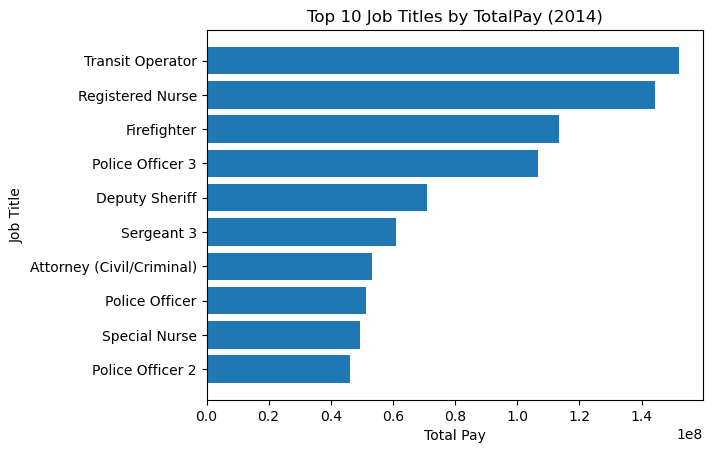

In [81]:
q5 = """
SELECT JobTitle, SUM(TotalPay) AS total_pay
FROM salaries
WHERE year = 2014
GROUP BY JobTitle
ORDER BY total_pay DESC
LIMIT 10
"""
df= pd.read_sql_query(q5, conn)

plt.figure()
plt.barh(df["JobTitle"], df["total_pay"])
plt.xlabel("Total Pay")
plt.ylabel("Job Title")
plt.title("Top 10 Job Titles by TotalPay (2014)")
plt.gca().invert_yaxis()
plt.show()


In [82]:
q6 = """
SELECT DISTINCT JobTitle, OvertimePay
FROM salaries
WHERE OvertimePay > 150000
AND JobTitle NOT IN ('Not Provided', 'Not provided')
"""
df= pd.read_sql_query(q6, conn)
print(df)


                       JobTitle  OvertimePay
0  Lieutenant, Fire Suppression    220909.48
1     EMT/Paramedic/Firefighter    192424.49
2                   Firefighter    160418.47
3  Lieutenant, Fire Suppression    163477.81
4                Deputy Sheriff    196689.18
5                Deputy Sheriff    156077.49
6                Deputy Sheriff    173547.73
7                Deputy Sheriff    173178.23
8                Deputy Sheriff    169659.92


In [83]:
q7 = """
SELECT EmployeeName, JobTitle
FROM salaries
WHERE JobTitle LIKE '%CHIEF%'
"""
df= pd.read_sql_query(q7, conn)
print(df)


            EmployeeName                                      JobTitle
0        PATRICK GARDNER  DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)
1         DAVID SULLIVAN                     ASSISTANT DEPUTY CHIEF II
2              ALSON LEE            BATTALION CHIEF, (FIRE DEPARTMENT)
3         MICHAEL MORRIS            BATTALION CHIEF, (FIRE DEPARTMENT)
4     JOANNE HAYES-WHITE        CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)
..                   ...                                           ...
622     Sharon C Jackson                Chief Deputy Adlt Probation Of
623          Anita S Lee                                   Chief Clerk
624     George D Vaughan                      Chief Nursery Specialist
625  Patrick W Gillespie                              Chief Preparator
626  Christopher L Ochoa                     Chief Stationary Engineer

[627 rows x 2 columns]


In [84]:
q8 = """
SELECT year, COUNT(*) AS employee_count
FROM salaries
WHERE year IN (2012, 2013)
AND (JobTitle LIKE '%ENGINEER%' OR JobTitle LIKE '%Fire%')
GROUP BY year
"""
df = pd.read_sql_query(q8, conn)
print(df)


   Year  employee_count
0  2012            2463
1  2013            2506


In [85]:
q9 = """
SELECT DISTINCT JobTitle
FROM salaries
WHERE JobTitle LIKE 'CAPTAIN%'
"""
df = pd.read_sql_query(q9, conn)
print(df)


                                            JobTitle
0                    CAPTAIN III (POLICE DEPARTMENT)
1              CAPTAIN, EMERGENCYCY MEDICAL SERVICES
2                          CAPTAIN, FIRE SUPPRESSION
3  CAPTAIN, BUREAU OF FIRE PREVENTION AND PUBLIC ...
4                                          Captain 3
5                          Captain, Fire Suppression
6                        Captain, Emergency Med Svcs
7                         Captain, (Fire Department)


In [86]:
q10 = """
SELECT EmployeeName, JobTitle, BasePay, TotalPay
FROM salaries
WHERE BasePay > 50000
AND TotalPay < 150000
AND EmployeeName NOT IN ('Not Provided', 'Not provided')
"""
df= pd.read_sql_query(q10, conn)
print(df)


               EmployeeName                                      JobTitle  \
0                 JAY DOWKE                            POLICE OFFICER III   
1               MURRAY BOND  MANAGER VI - MUNICIPAL TRANSPORTATION AGENCY   
2               MARILOU GAN                              REGISTERED NURSE   
3             BRIAN COLLINS                                   FIREFIGHTER   
4              GREGORY NEAL                              POLICE OFFICER I   
...                     ...                                           ...   
87253         Renee J Allen                                 Special Nurse   
87254  Melody M Butterworth                     Attorney (Civil/Criminal)   
87255       Stephanie Reidy                                 Special Nurse   
87256        Paul E Maltzer                                     Planner 5   
87257     Kathleen N Yumang                                 Special Nurse   

         BasePay   TotalPay  
0      112380.37  149987.24  
1       149975.